In [1]:
# Imports et configuration generale
#
# Ce fichier est ecrit au format "notebook Python" :
# chaque bloc "# %%" correspond a une cellule Jupyter/VS Code.

from __future__ import annotations

import gc
import math
import os
import random
import re
import time
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    top_k_accuracy_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

PROJECT_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_ROOT = PROJECT_DIR / "data"
ALL_IMAGES_DIR = DATA_ROOT / "all_images"
ALL_IMAGES_LABELS_CSV = DATA_ROOT / "files_df.csv"
DATA_LAYOUT = "all_images"

MODEL_SAVE_DIR = PROJECT_DIR / "notebooks" / "models_pt"
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = DEVICE.type == "cuda"
USE_AMP = DEVICE.type == "cuda"

print("PyTorch version         :", torch.__version__)
print("Torchvision version     :", torchvision.__version__)
print("Data root exists        :", DATA_ROOT.exists())
print("All images dir exists   :", ALL_IMAGES_DIR.exists())
print("All images labels csv   :", ALL_IMAGES_LABELS_CSV.exists())
print("Selected data layout    :", DATA_LAYOUT)
print("Model save dir          :", MODEL_SAVE_DIR)
print("Device                  :", DEVICE)
print("GPU available           :", torch.cuda.is_available())

PyTorch version         : 2.10.0+cu128
Torchvision version     : 0.25.0+cu128
Data root exists        : True
All images dir exists   : True
All images labels csv   : True
Selected data layout    : all_images
Model save dir          : /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models_pt
Device                  : cuda
GPU available           : True


In [2]:
# Construire un DataFrame a partir de data/all_images et du CSV de labels.
#
# On garde volontairement la meme logique que dans le notebook TensorFlow :
# - lecture des fichiers de all_images
# - jointure avec files_df.csv si present
# - fallback sur le nom de fichier si besoin

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def extract_label_from_filename(filename: str) -> str:
    match = re.match(r"(.+)_\d+\.[^.]+$", filename)
    if not match:
        raise ValueError(f"Nom de fichier inattendu : {filename}")
    return match.group(1)


def build_df_from_all_images(all_images_dir: Path, labels_csv_path: Path | None = None) -> pd.DataFrame:
    image_paths = sorted(
        [p for p in all_images_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
    )

    files_df = pd.DataFrame(
        {
            "filepath": [str(p) for p in image_paths],
            "filename": [p.name for p in image_paths],
        }
    )

    if labels_csv_path is not None and labels_csv_path.exists():
        labels_df = pd.read_csv(labels_csv_path)
        required_columns = {"filename", "name"}
        missing_columns = required_columns - set(labels_df.columns)
        if missing_columns:
            raise ValueError(
                f"Le CSV {labels_csv_path} doit contenir les colonnes {required_columns}, "
                f"colonnes manquantes : {missing_columns}"
            )

        labels_df = (
            labels_df[["filename", "name"]]
            .assign(filename=lambda df_: df_["filename"].astype(str).map(lambda path: Path(path).name))
            .drop_duplicates(subset=["filename"])
            .rename(columns={"name": "label"})
        )

        df_local = files_df.merge(labels_df, on="filename", how="left", validate="one_to_one")
        missing_labels = int(df_local["label"].isna().sum())
        if missing_labels > 0:
            missing_files = df_local.loc[df_local["label"].isna(), "filename"].head(10).tolist()
            raise ValueError(
                f"{missing_labels} image(s) de all_images n'ont pas de label dans {labels_csv_path}. "
                f"Exemples : {missing_files}"
            )

        unused_csv_rows = labels_df.loc[~labels_df["filename"].isin(files_df["filename"])]
        if len(unused_csv_rows) > 0:
            print(f"Attention : {len(unused_csv_rows)} ligne(s) du CSV ne correspondent a aucun fichier dans all_images.")

        label_source = labels_csv_path.name
    else:
        df_local = files_df.copy()
        df_local["label"] = df_local["filename"].apply(extract_label_from_filename)
        label_source = "filename"

    df_local["data_layout"] = "all_images"
    df_local["label_source"] = label_source
    return df_local


if DATA_LAYOUT != "all_images":
    raise ValueError("Ce notebook PyTorch est prepare pour DATA_LAYOUT='all_images'.")

df = build_df_from_all_images(ALL_IMAGES_DIR, ALL_IMAGES_LABELS_CSV)

if df.empty:
    raise ValueError("Aucune image trouvee dans data/all_images.")

print(f"Source selectionnee     : {ALL_IMAGES_DIR}")
print(f"Nombre total d'images   : {len(df)}")
print(f"Nombre de classes       : {df['label'].nunique()}")
print(f"Source des labels       : {df['label_source'].iloc[0]}")
display(df.head())

Source selectionnee     : /home/thomashebert99/code/thomashebert99/plant_detect/data/all_images
Nombre total d'images   : 7314
Nombre de classes       : 23
Source des labels       : files_df.csv


,filepath,filename,label,data_layout,label_source
0,/home/thomashebert99/code/thomashebert99/plant...,aneth_0001.jpg,dill,all_images,files_df.csv
1,/home/thomashebert99/code/thomashebert99/plant...,aneth_0003.jpg,dill,all_images,files_df.csv
2,/home/thomashebert99/code/thomashebert99/plant...,aneth_0004.jpg,dill,all_images,files_df.csv
3,/home/thomashebert99/code/thomashebert99/plant...,aneth_0005.jpg,dill,all_images,files_df.csv
4,/home/thomashebert99/code/thomashebert99/plant...,aneth_0007.jpg,dill,all_images,files_df.csv


In [3]:
try:
    df = build_df_from_all_images(ALL_IMAGES_DIR, ALL_IMAGES_LABELS_CSV)
    print("OK")
    print(df.shape)
    print(df.head())
except Exception as e:
    import traceback
    traceback.print_exc()


OK
(7314, 5)
                                            filepath        filename label  \
0  /home/thomashebert99/code/thomashebert99/plant...  aneth_0001.jpg  dill   
1  /home/thomashebert99/code/thomashebert99/plant...  aneth_0003.jpg  dill   
2  /home/thomashebert99/code/thomashebert99/plant...  aneth_0004.jpg  dill   
3  /home/thomashebert99/code/thomashebert99/plant...  aneth_0005.jpg  dill   
4  /home/thomashebert99/code/thomashebert99/plant...  aneth_0007.jpg  dill   

  data_layout  label_source  
0  all_images  files_df.csv  
1  all_images  files_df.csv  
2  all_images  files_df.csv  
3  all_images  files_df.csv  
4  all_images  files_df.csv  


label
angelica        435
basil           187
borage          226
chamomile       441
chives          414
coriander       208
dill            252
fennel          479
hyssop          312
lavender        186
lemongrass      294
lemonverbena    342
lovage          270
mint            393
mugwort         179
oregano         399
parsley         402
rosemary        205
sage            437
savory          203
tarragon        378
thyme           485
wintergreen     187
Name: count, dtype: int64

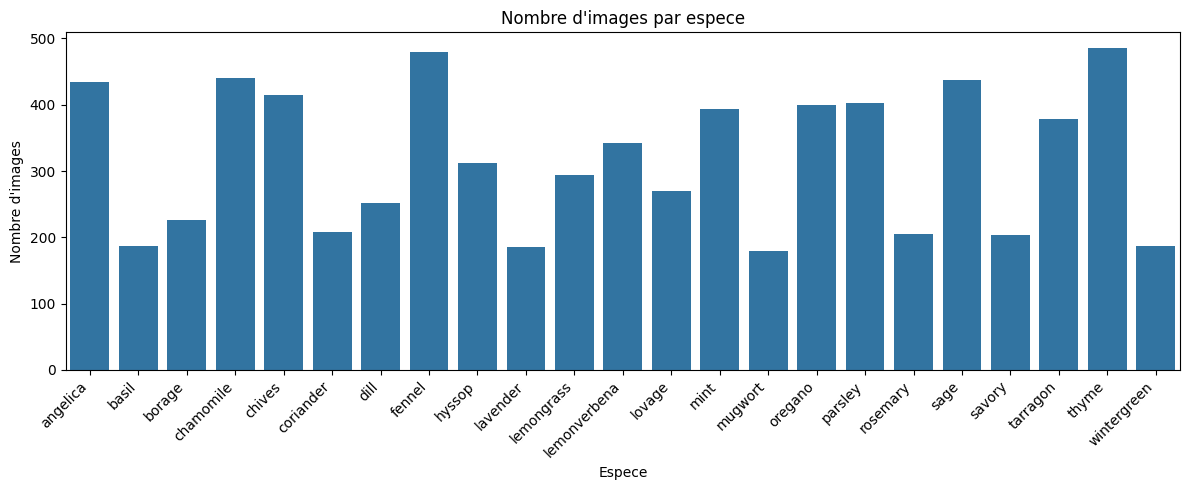

In [4]:
# Verification rapide de la distribution des classes.
#
# Le dataset est desequilibre, donc on utilisera :
# - un split stratifie
# - un ranking multicritere
# - des class weights quand cela aide

class_counts = df["label"].value_counts().sort_index()
display(class_counts)

plt.figure(figsize=(12, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Nombre d'images par espece")
plt.xlabel("Espece")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
# Selection de 10 candidats PyTorch realistes pour ce dataset.
#
# Comme timm n'est pas installe ici, on prend une selection forte et
# directement disponible via torchvision.
#
# L'idee est d'avoir un melange de backbones :
# - mobiles / compacts
# - efficaces en transfer learning
# - plus capacitaires pour aller chercher de meilleures representations

PT_MODELS = {
    "mobilenet_v3_large": {"family": "mobilenet", "batch_size": 48},
    "efficientnet_b0": {"family": "efficientnet", "batch_size": 48},
    "efficientnet_b2": {"family": "efficientnet", "batch_size": 32},
    "efficientnet_b3": {"family": "efficientnet", "batch_size": 24},
    "efficientnet_b4": {"family": "efficientnet", "batch_size": 8},
    "efficientnet_v2_s": {"family": "efficientnet", "batch_size": 4},
    "resnet50": {"family": "resnet", "batch_size": 48},
    "densenet121": {"family": "densenet", "batch_size": 32},
    "convnext_tiny": {"family": "convnext", "batch_size": 24},
    "regnet_y_1_6gf": {"family": "regnet", "batch_size": 24},
}

for model_name, spec in PT_MODELS.items():
    weights = models.get_model_weights(model_name).DEFAULT
    preset = weights.transforms()
    spec["weights"] = weights
    spec["input_size"] = int(preset.crop_size[0] if isinstance(preset.crop_size, (list, tuple)) else preset.crop_size)
    spec["resize_size"] = int(
        preset.resize_size[0] if isinstance(preset.resize_size, (list, tuple)) else preset.resize_size
    )
    spec["mean"] = list(preset.mean)
    spec["std"] = list(preset.std)
    spec["interpolation"] = preset.interpolation

CANDIDATE_MODELS = list(PT_MODELS.keys())

print("Nombre de classes :", df["label"].nunique())
print("Modeles PyTorch retenus :", CANDIDATE_MODELS)
display(
    pd.DataFrame(
        [
            {
                "model_name": model_name,
                "family": spec["family"],
                "input_size": spec["input_size"],
                "resize_size": spec["resize_size"],
                "batch_size": spec["batch_size"],
            }
            for model_name, spec in PT_MODELS.items()
        ]
    )
)

Nombre de classes : 23
Modeles PyTorch retenus : ['mobilenet_v3_large', 'efficientnet_b0', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_v2_s', 'resnet50', 'densenet121', 'convnext_tiny', 'regnet_y_1_6gf']


,model_name,family,input_size,resize_size,batch_size
0,mobilenet_v3_large,mobilenet,224,232,48
1,efficientnet_b0,efficientnet,224,256,48
2,efficientnet_b2,efficientnet,288,288,32
3,efficientnet_b3,efficientnet,300,320,24
4,efficientnet_b4,efficientnet,380,384,8
5,efficientnet_v2_s,efficientnet,384,384,4
6,resnet50,resnet,224,232,48
7,densenet121,densenet,224,256,32
8,convnext_tiny,convnext,224,236,24
9,regnet_y_1_6gf,regnet,224,232,24


Train size : 5119
Val size   : 1097
Test size  : 1098


label,angelica,basil,borage,chamomile,chives,coriander,dill,fennel,hyssop,lavender,...,mint,mugwort,oregano,parsley,rosemary,sage,savory,tarragon,thyme,wintergreen
split,,,,,,,,,,,,,,,,,,,,,
test,65,28,34,66,62,31,38,72,47,28,...,59,27,60,60,31,66,30,57,73,28
train,305,131,158,309,290,146,176,335,218,130,...,275,125,279,282,143,306,142,264,339,131
val,65,28,34,66,62,31,38,72,47,28,...,59,27,60,60,31,65,31,57,73,28


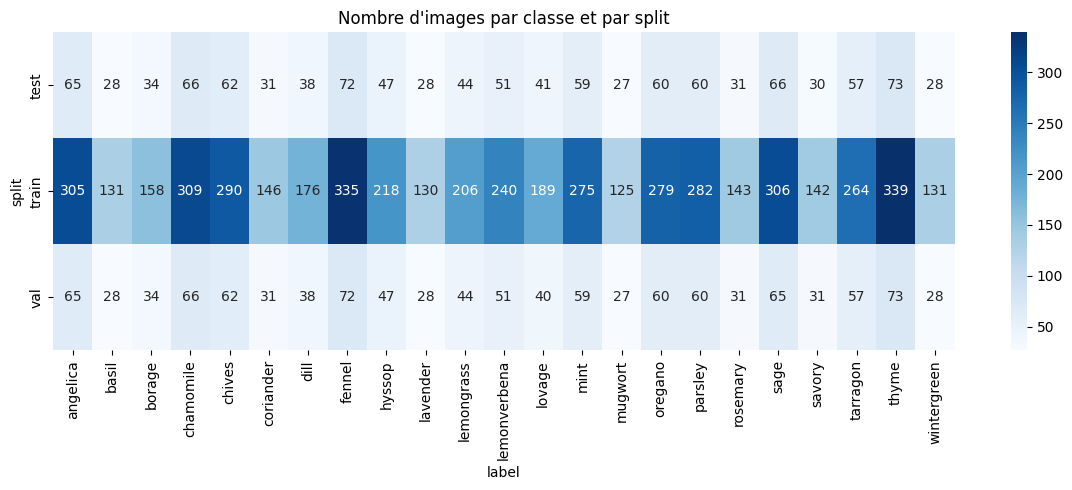

In [6]:
# Split train / validation / test stratifie.
#
# On reprend la meme logique que le notebook TensorFlow :
# - 15% test
# - 15% validation
# - stratification sur le label

TEST_SIZE = 0.15
VAL_SIZE = 0.15
RANDOM_STATE = SEED

CLASS_NAMES = sorted(df["label"].unique())
NUM_CLASSES = len(CLASS_NAMES)
TOP_K = min(3, NUM_CLASSES)

label_to_index = {label: idx for idx, label in enumerate(CLASS_NAMES)}
index_to_label = {idx: label for label, idx in label_to_index.items()}

df_train_val, df_test = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["label"],
    random_state=RANDOM_STATE,
)

val_relative_size = VAL_SIZE / (1 - TEST_SIZE)

df_train, df_val = train_test_split(
    df_train_val,
    test_size=val_relative_size,
    stratify=df_train_val["label"],
    random_state=RANDOM_STATE,
)

for split_df in (df_train, df_val, df_test):
    split_df["label_id"] = split_df["label"].map(label_to_index)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Train size :", len(df_train))
print("Val size   :", len(df_val))
print("Test size  :", len(df_test))

split_summary = (
    pd.concat(
        [
            df_train.assign(split="train"),
            df_val.assign(split="val"),
            df_test.assign(split="test"),
        ],
        ignore_index=True,
    )
    .groupby(["split", "label"])
    .size()
    .unstack(fill_value=0)
)

display(split_summary)

plt.figure(figsize=(12, 5))
sns.heatmap(split_summary, annot=True, cmap="Blues", fmt="d")
plt.title("Nombre d'images par classe et par split")
plt.tight_layout()
plt.show()

In [7]:
# Dataset PyTorch et transformations par modele.
#
# Point important :
# chaque backbone conserve la normalisation ImageNet attendue par ses
# poids pretrained, mais on ajoute un peu d'augmentation en train.


class HerbsDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, index: int):
        row = self.dataframe.iloc[index]
        image = Image.open(row["filepath"]).convert("RGB")
        label = int(row["label_id"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label


def make_transforms(model_name: str, train: bool):
    spec = PT_MODELS[model_name]
    input_size = spec["input_size"]
    resize_size = spec["resize_size"]
    mean = spec["mean"]
    std = spec["std"]
    interpolation = spec["interpolation"]

    if train:
        return transforms.Compose(
            [
                transforms.RandomResizedCrop(
                    input_size,
                    scale=(0.75, 1.0),
                    interpolation=interpolation,
                ),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(degrees=12),
                transforms.ColorJitter(
                    brightness=0.12,
                    contrast=0.12,
                    saturation=0.12,
                    hue=0.02,
                ),
                transforms.ToTensor(),
                transforms.Normalize(mean=mean, std=std),
            ]
        )

    return transforms.Compose(
        [
            transforms.Resize(resize_size, interpolation=interpolation),
            transforms.CenterCrop(input_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=mean, std=std),
        ]
    )


def make_dataloader(
    dataframe: pd.DataFrame,
    model_name: str,
    train: bool,
    shuffle: bool,
    batch_size: int | None = None,
) -> DataLoader:
    spec = PT_MODELS[model_name]
    dataset = HerbsDataset(dataframe, transform=make_transforms(model_name, train=train))
    effective_batch_size = batch_size or spec["batch_size"]

    return DataLoader(
        dataset,
        batch_size=effective_batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
    )


print("Classes :", CLASS_NAMES)
print("Nombre de classes :", NUM_CLASSES)
print("Exemple d'input size EfficientNetV2S :", PT_MODELS["efficientnet_v2_s"]["input_size"])

Classes : ['angelica', 'basil', 'borage', 'chamomile', 'chives', 'coriander', 'dill', 'fennel', 'hyssop', 'lavender', 'lemongrass', 'lemonverbena', 'lovage', 'mint', 'mugwort', 'oregano', 'parsley', 'rosemary', 'sage', 'savory', 'tarragon', 'thyme', 'wintergreen']
Nombre de classes : 23
Exemple d'input size EfficientNetV2S : 384


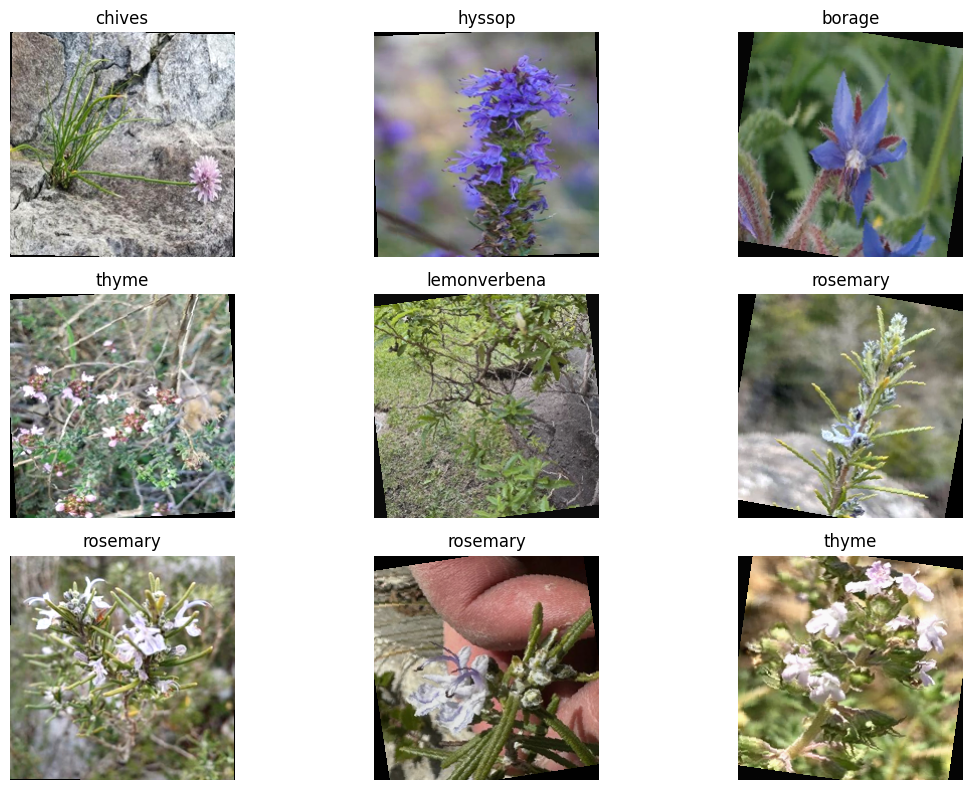

In [8]:
# Verification visuelle rapide d'un batch.
#
# Cette cellule est optionnelle mais utile pour confirmer :
# - que le chargement fonctionne
# - que les labels sont bons
# - que l'augmentation n'est pas trop agressive


def denormalize_image(tensor: torch.Tensor, mean: list[float], std: list[float]) -> np.ndarray:
    image = tensor.detach().cpu().clone()
    for channel, (channel_mean, channel_std) in enumerate(zip(mean, std)):
        image[channel] = image[channel] * channel_std + channel_mean
    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    return image


VISUAL_MODEL_NAME = "efficientnet_b0"
visual_loader = make_dataloader(df_train, VISUAL_MODEL_NAME, train=True, shuffle=True)
visual_images, visual_labels = next(iter(visual_loader))

plt.figure(figsize=(12, 8))
for idx in range(min(9, len(visual_images))):
    plt.subplot(3, 3, idx + 1)
    plt.imshow(
        denormalize_image(
            visual_images[idx],
            PT_MODELS[VISUAL_MODEL_NAME]["mean"],
            PT_MODELS[VISUAL_MODEL_NAME]["std"],
        )
    )
    plt.title(index_to_label[int(visual_labels[idx])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Hyperparametres globaux.
#
# On garde le meme esprit que le notebook TF :
# - phase 1 : head-only
# - class weights activees pour all_images
# - fine-tuning ensuite seulement sur le top 4

HEAD_EPOCHS = 20
HEAD_LEARNING_RATE = 1e-3
DROPOUT_RATE = 0.30
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4

USE_CLASS_WEIGHTS = DATA_LAYOUT == "all_images"
CONFUSION_NORMALIZE = "true"


def build_class_weight_tensor(dataframe: pd.DataFrame) -> torch.Tensor | None:
    if not USE_CLASS_WEIGHTS:
        return None

    classes = np.array(sorted(dataframe["label_id"].unique()))
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=dataframe["label_id"].values,
    )
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


CLASS_WEIGHT_TENSOR = build_class_weight_tensor(df_train)

print("USE_CLASS_WEIGHTS :", USE_CLASS_WEIGHTS)
if CLASS_WEIGHT_TENSOR is not None:
    display(pd.Series(CLASS_WEIGHT_TENSOR.detach().cpu().numpy(), index=CLASS_NAMES, name="class_weight"))

USE_CLASS_WEIGHTS : True


angelica        0.729722
basil           1.698971
borage          1.408641
chamomile       0.720276
chives          0.767466
coriander       1.524419
dill            1.264575
fennel          0.664374
hyssop          1.020941
lavender        1.712040
lemongrass      1.080414
lemonverbena    0.927355
lovage          1.177594
mint            0.809328
mugwort         1.780522
oregano         0.797725
parsley         0.789238
rosemary        1.556400
sage            0.727337
savory          1.567361
tarragon        0.843050
thyme           0.656535
wintergreen     1.698971
Name: class_weight, dtype: float32

In [10]:
# Outils de construction des modeles.
#
# On remplace uniquement la tete de classification au depart.
# Le backbone reste gele pendant le benchmark head-only.


def count_params_millions(model: nn.Module) -> float:
    return sum(param.numel() for param in model.parameters()) / 1_000_000


def replace_classifier_head(model: nn.Module, num_classes: int, dropout_rate: float = 0.30) -> nn.Module:
    if hasattr(model, "fc") and isinstance(model.fc, nn.Linear):
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes),
        )
        return model

    if hasattr(model, "classifier"):
        classifier = model.classifier

        if isinstance(classifier, nn.Linear):
            model.classifier = nn.Sequential(
                nn.Dropout(dropout_rate),
                nn.Linear(classifier.in_features, num_classes),
            )
            return model

        if isinstance(classifier, nn.Sequential):
            layers = list(classifier.children())
            last_linear_idx = None
            for idx in range(len(layers) - 1, -1, -1):
                if isinstance(layers[idx], nn.Linear):
                    last_linear_idx = idx
                    break

            if last_linear_idx is None:
                raise ValueError(f"Impossible de trouver une couche Linear dans classifier pour {type(model).__name__}")

            in_features = layers[last_linear_idx].in_features
            layers[last_linear_idx] = nn.Linear(in_features, num_classes)
            model.classifier = nn.Sequential(*layers)
            return model

    raise ValueError(f"Architecture non geree pour remplacer la tete : {type(model).__name__}")


def is_head_parameter(name: str) -> bool:
    return name.startswith(("fc", "classifier"))


def freeze_backbone(model: nn.Module) -> None:
    for name, param in model.named_parameters():
        param.requires_grad = is_head_parameter(name)


def get_backbone_blocks(model: nn.Module, family: str) -> list[nn.Module]:
    if family in {"efficientnet", "mobilenet", "convnext", "densenet"}:
        return list(model.features.children())

    if family == "resnet":
        return [
            model.conv1,
            model.bn1,
            model.relu,
            model.maxpool,
            model.layer1,
            model.layer2,
            model.layer3,
            model.layer4,
        ]

    if family == "regnet":
        return [model.stem, *list(model.trunk_output.children())]

    raise ValueError(f"Famille non geree pour le fine-tuning : {family}")


def set_fine_tune_layers(
    model: nn.Module,
    model_name: str,
    unfreeze_fraction: float = 0.30,
    freeze_batchnorm: bool = True,
):
    freeze_backbone(model)

    family = PT_MODELS[model_name]["family"]
    blocks = get_backbone_blocks(model, family)
    n_unfreeze = max(1, math.ceil(len(blocks) * unfreeze_fraction))

    for block in blocks[-n_unfreeze:]:
        for param in block.parameters():
            param.requires_grad = True

    if freeze_batchnorm:
        for module in model.modules():
            if isinstance(module, nn.modules.batchnorm._BatchNorm):
                for param in module.parameters():
                    param.requires_grad = False

    trainable_backbone_params = sum(
        param.numel()
        for name, param in model.named_parameters()
        if param.requires_grad and not is_head_parameter(name)
    )

    return n_unfreeze, trainable_backbone_params


def set_batchnorm_eval(model: nn.Module) -> None:
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()


def build_transfer_model(model_name: str, num_classes: int, dropout_rate: float = 0.30) -> nn.Module:
    spec = PT_MODELS[model_name]
    model = models.get_model(model_name, weights=spec["weights"])
    model = replace_classifier_head(model, num_classes=num_classes, dropout_rate=dropout_rate)
    freeze_backbone(model)
    return model

In [11]:
# Metriques de ranking multiclasses.
#
# On reprend la logique du notebook TF :
# un score composite robuste au desequilibre, au lieu de se limiter
# a la seule accuracy.


def compute_ranking_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> dict[str, float]:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "top_3_accuracy": top_k_accuracy_score(
            y_true,
            y_proba,
            k=TOP_K,
            labels=np.arange(NUM_CLASSES),
        ),
        "log_loss": log_loss(y_true, y_proba, labels=np.arange(NUM_CLASSES)),
    }

    metrics["ranking_score"] = (
        0.45 * metrics["macro_f1"]
        + 0.30 * metrics["balanced_accuracy"]
        + 0.15 * metrics["top_3_accuracy"]
        + 0.10 * metrics["accuracy"]
    )
    return metrics

In [12]:
# Boucles d'entrainement / evaluation.
#
# Le but est d'avoir un moteur unique pour :
# - le benchmark head-only
# - le fine-tuning des meilleurs modeles


def clear_memory() -> None:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def get_current_lr(optimizer: torch.optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def save_checkpoint(
    checkpoint_path: Path,
    model: nn.Module,
    model_name: str,
    metrics: dict[str, float],
    run_config: dict,
) -> None:
    payload = {
        "model_name": model_name,
        "state_dict": model.state_dict(),
        "metrics": metrics,
        "run_config": run_config,
        "class_names": CLASS_NAMES,
        "num_classes": NUM_CLASSES,
    }
    torch.save(payload, checkpoint_path)


def load_model_from_checkpoint(checkpoint_path: Path) -> tuple[nn.Module, dict]:
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    model_name = checkpoint["model_name"]
    run_config = checkpoint["run_config"]

    model = build_transfer_model(
        model_name=model_name,
        num_classes=checkpoint["num_classes"],
        dropout_rate=run_config["dropout_rate"],
    )
    model.load_state_dict(checkpoint["state_dict"])
    return model, checkpoint


def evaluate_dataloader(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module | None = None,
    split_name: str = "val",
    use_amp: bool | None = None,
):
    model.to(DEVICE)
    model.eval()

    effective_use_amp = USE_AMP if use_amp is None else use_amp

    total_loss = 0.0
    sample_count = 0
    y_true_batches = []
    y_pred_batches = []
    y_proba_batches = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.autocast(device_type=DEVICE.type, enabled=effective_use_amp):
                logits = model(images)

                if not torch.isfinite(logits).all():
                    raise RuntimeError(
                        f"NaN/Inf detectes dans les logits pendant l'evaluation "
                        f"(split={split_name}, batch={batch_idx})."
                    )

                if criterion is not None:
                    loss = criterion(logits, labels)
                    if not torch.isfinite(loss):
                        raise RuntimeError(
                            f"NaN/Inf detectes dans la loss pendant l'evaluation "
                            f"(split={split_name}, batch={batch_idx})."
                        )
                    total_loss += loss.item() * images.size(0)

            probabilities = torch.softmax(logits, dim=1)

            if not torch.isfinite(probabilities).all():
                raise RuntimeError(
                    f"NaN/Inf detectes dans les probabilites pendant l'evaluation "
                    f"(split={split_name}, batch={batch_idx})."
                )

            predictions = probabilities.argmax(dim=1)

            sample_count += images.size(0)
            y_true_batches.append(labels.detach().cpu().numpy())
            y_pred_batches.append(predictions.detach().cpu().numpy())
            y_proba_batches.append(probabilities.detach().cpu().numpy())

    y_true = np.concatenate(y_true_batches)
    y_pred = np.concatenate(y_pred_batches)
    y_proba = np.concatenate(y_proba_batches)

    metrics = compute_ranking_metrics(y_true, y_pred, y_proba)
    metrics.update(
        {
            "split": split_name,
            "loss": total_loss / sample_count if criterion is not None else np.nan,
        }
    )

    return {
        "metrics": metrics,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler,
    freeze_batchnorm: bool = False,
    use_amp: bool | None = None,
) -> dict[str, float]:
    model.to(DEVICE)
    model.train()

    if freeze_batchnorm:
        set_batchnorm_eval(model)

    effective_use_amp = USE_AMP if use_amp is None else use_amp

    total_loss = 0.0
    sample_count = 0
    y_true_batches = []
    y_pred_batches = []

    for batch_idx, (images, labels) in enumerate(dataloader):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=DEVICE.type, enabled=effective_use_amp):
            logits = model(images)

            if not torch.isfinite(logits).all():
                raise RuntimeError(
                    f"NaN/Inf detectes dans les logits pendant l'entrainement "
                    f"(batch={batch_idx})."
                )

            loss = criterion(logits, labels)

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f"NaN/Inf detectes dans la loss pendant l'entrainement "
                    f"(batch={batch_idx})."
                )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        sample_count += images.size(0)
        y_true_batches.append(labels.detach().cpu().numpy())
        y_pred_batches.append(predictions.detach().cpu().numpy())

    y_true = np.concatenate(y_true_batches)
    y_pred = np.concatenate(y_pred_batches)

    return {
        "loss": total_loss / sample_count,
        "accuracy": accuracy_score(y_true, y_pred),
    }


def fit_model(
    model: nn.Module,
    model_name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    epochs: int,
    checkpoint_path: Path,
    run_config: dict,
    monitor_metric: str,
    monitor_mode: str,
    scheduler_metric: str,
    scheduler_mode: str,
    patience: int = 4,
    freeze_batchnorm: bool = False,
    use_amp: bool | None = None,
):
    effective_use_amp = USE_AMP if use_amp is None else use_amp

    scaler = torch.amp.GradScaler(
        DEVICE.type,
        enabled=effective_use_amp,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode=scheduler_mode,
        factor=0.3 if scheduler_mode == "min" else 0.5,
        patience=2,
        min_lr=1e-6 if scheduler_mode == "min" else 1e-7,
    )

    history_rows = []
    best_monitor_value = -float("inf") if monitor_mode == "max" else float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        train_stats = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler,
            freeze_batchnorm=freeze_batchnorm,
            use_amp=effective_use_amp,
        )

        val_eval = evaluate_dataloader(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            split_name="val",
            use_amp=effective_use_amp,
        )
        val_metrics = val_eval["metrics"]

        epoch_row = {
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "train_accuracy": train_stats["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_macro_precision": val_metrics["macro_precision"],
            "val_macro_recall": val_metrics["macro_recall"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_weighted_f1": val_metrics["weighted_f1"],
            "val_top_3_accuracy": val_metrics["top_3_accuracy"],
            "val_log_loss": val_metrics["log_loss"],
            "val_ranking_score": val_metrics["ranking_score"],
            "lr": get_current_lr(optimizer),
            "epoch_time_sec": time.time() - epoch_start,
        }
        history_rows.append(epoch_row)

        monitor_value = epoch_row[monitor_metric]
        scheduler_value = epoch_row[scheduler_metric]

        improved = (
            monitor_value > best_monitor_value
            if monitor_mode == "max"
            else monitor_value < best_monitor_value
        )

        if improved:
            best_monitor_value = monitor_value
            epochs_without_improvement = 0
            save_checkpoint(
                checkpoint_path=checkpoint_path,
                model=model,
                model_name=model_name,
                metrics=epoch_row,
                run_config=run_config,
            )
            print(
                f"Epoch {epoch:02d}: new best {monitor_metric}={monitor_value:.4f} "
                f"-> checkpoint saved to {checkpoint_path}"
            )
        else:
            epochs_without_improvement += 1

        scheduler.step(scheduler_value)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={epoch_row['train_loss']:.4f} | "
            f"train_acc={epoch_row['train_accuracy']:.4f} | "
            f"val_loss={epoch_row['val_loss']:.4f} | "
            f"val_acc={epoch_row['val_accuracy']:.4f} | "
            f"val_macro_f1={epoch_row['val_macro_f1']:.4f} | "
            f"val_rank={epoch_row['val_ranking_score']:.4f} | "
            f"lr={epoch_row['lr']:.2e}"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping after epoch {epoch}.")
            break

    best_model, checkpoint = load_model_from_checkpoint(checkpoint_path)
    history_df = pd.DataFrame(history_rows)

    return {
        "model_name": model_name,
        "model": best_model.cpu(),
        "checkpoint_path": checkpoint_path,
        "history": history_df,
        "best_metrics": checkpoint["metrics"],
        "run_config": run_config,
    }


def build_criterion(
    class_weights: torch.Tensor | None = None,
    label_smoothing: float = 0.0,
) -> nn.Module:
    return nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=label_smoothing,
    )


def train_head_only_model(
    model_name: str,
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    epochs: int = HEAD_EPOCHS,
    learning_rate: float = HEAD_LEARNING_RATE,
    dropout_rate: float = DROPOUT_RATE,
    use_class_weights: bool = USE_CLASS_WEIGHTS,
):
    spec = PT_MODELS[model_name]
    train_loader = make_dataloader(df_train, model_name=model_name, train=True, shuffle=True)
    val_loader = make_dataloader(df_val, model_name=model_name, train=False, shuffle=False)

    model = build_transfer_model(model_name=model_name, num_classes=NUM_CLASSES, dropout_rate=dropout_rate)
    model = model.to(DEVICE)

    class_weights = build_class_weight_tensor(df_train) if use_class_weights else None
    criterion = build_criterion(class_weights=class_weights, label_smoothing=0.0)

    effective_learning_rate = learning_rate
    effective_use_amp = USE_AMP

    if model_name == "efficientnet_v2_s":
        effective_learning_rate = 1e-4
        effective_use_amp = False

    optimizer = torch.optim.AdamW(
        [param for param in model.parameters() if param.requires_grad],
        lr=effective_learning_rate,
        weight_decay=WEIGHT_DECAY,
    )

    checkpoint_path = MODEL_SAVE_DIR / f"{model_name}_head_only_best.pt"
    run_config = {
        "phase": "head_only",
        "dropout_rate": dropout_rate,
        "learning_rate": effective_learning_rate,
        "epochs": epochs,
        "batch_size": spec["batch_size"],
        "input_size": spec["input_size"],
        "use_class_weights": use_class_weights,
        "use_amp": effective_use_amp,
    }

    print(f"Class weights actifs pour {model_name} : {use_class_weights}")
    print(f"input_size={spec['input_size']}, batch_size={spec['batch_size']}")
    print(f"learning_rate={effective_learning_rate}, use_amp={effective_use_amp}")

    start_time = time.time()
    run = fit_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        epochs=epochs,
        checkpoint_path=checkpoint_path,
        run_config=run_config,
        monitor_metric="val_accuracy",
        monitor_mode="max",
        scheduler_metric="val_loss",
        scheduler_mode="min",
        patience=EARLY_STOPPING_PATIENCE,
        freeze_batchnorm=True,
        use_amp=effective_use_amp,
    )
    run["train_time_min"] = (time.time() - start_time) / 60
    run["params_millions"] = count_params_millions(run["model"])
    clear_memory()
    return run


In [13]:
# Test optionnel sur un seul modele.
#
# Laisse RUN_SMOKE_TEST = False si tu veux aller directement au benchmark
# des 10 modeles.

RUN_SMOKE_TEST = False
SMOKE_TEST_MODEL = "efficientnet_b0"

if RUN_SMOKE_TEST:
    smoke_run = train_head_only_model(
        model_name=SMOKE_TEST_MODEL,
        df_train=df_train,
        df_val=df_val,
    )
    display(smoke_run["history"].head())

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(smoke_run["history"]["train_loss"], label="train_loss")
    plt.plot(smoke_run["history"]["val_loss"], label="val_loss")
    plt.title(f"{SMOKE_TEST_MODEL} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(smoke_run["history"]["train_accuracy"], label="train_accuracy")
    plt.plot(smoke_run["history"]["val_accuracy"], label="val_accuracy")
    plt.title(f"{SMOKE_TEST_MODEL} - Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("RUN_SMOKE_TEST=False -> cellule sautee.")

RUN_SMOKE_TEST=False -> cellule sautee.


In [14]:
print("cwd:", Path.cwd())
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("ALL_IMAGES_DIR:", ALL_IMAGES_DIR)
print("ALL_IMAGES_DIR exists:", ALL_IMAGES_DIR.exists())
print("ALL_IMAGES_LABELS_CSV:", ALL_IMAGES_LABELS_CSV)
print("ALL_IMAGES_LABELS_CSV exists:", ALL_IMAGES_LABELS_CSV.exists())
print("DATA_LAYOUT:", DATA_LAYOUT)

cwd: /home/thomashebert99/code/thomashebert99/plant_detect/notebooks
PROJECT_DIR: /home/thomashebert99/code/thomashebert99/plant_detect
DATA_ROOT exists: True
ALL_IMAGES_DIR: /home/thomashebert99/code/thomashebert99/plant_detect/data/all_images
ALL_IMAGES_DIR exists: True
ALL_IMAGES_LABELS_CSV: /home/thomashebert99/code/thomashebert99/plant_detect/data/files_df.csv
ALL_IMAGES_LABELS_CSV exists: True
DATA_LAYOUT: all_images


In [15]:
# Benchmark head-only sur les 10 candidats.
#
# C'est la phase equivalente au benchmark TF avant fine-tuning.

benchmark_runs: dict[str, dict] = {}
benchmark_rows: list[dict] = []

for model_name in CANDIDATE_MODELS:
    print(f"\n{'=' * 18} {model_name} {'=' * 18}")
    clear_memory()

    run = train_head_only_model(
        model_name=model_name,
        df_train=df_train,
        df_val=df_val,
        epochs=HEAD_EPOCHS,
        learning_rate=HEAD_LEARNING_RATE,
        dropout_rate=DROPOUT_RATE,
        use_class_weights=USE_CLASS_WEIGHTS,
    )

    history_df = run["history"]
    best_idx = history_df["val_accuracy"].idxmax()
    spec = PT_MODELS[model_name]

    benchmark_runs[model_name] = run
    benchmark_rows.append(
        {
            "model_name": model_name,
            "best_val_accuracy": history_df.loc[best_idx, "val_accuracy"],
            "val_loss_at_best": history_df.loc[best_idx, "val_loss"],
            "train_accuracy_at_best": history_df.loc[best_idx, "train_accuracy"],
            "epochs_ran": len(history_df),
            "best_epoch": int(history_df.loc[best_idx, "epoch"]),
            "train_time_min": run["train_time_min"],
            "input_size": spec["input_size"],
            "batch_size": spec["batch_size"],
            "params_millions": run["params_millions"],
            "checkpoint_path": str(run["checkpoint_path"]),
        }
    )

benchmark_results_df = pd.DataFrame(benchmark_rows).sort_values(
    by="best_val_accuracy",
    ascending=False,
).reset_index(drop=True)

display(benchmark_results_df)


================== mobilenet_v3_large ==================
Class weights actifs pour mobilenet_v3_large : True
input_size=224, batch_size=48
learning_rate=0.001, use_amp=True


Epoch 01: new best val_accuracy=0.6454 -> checkpoint saved to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models_pt/mobilenet_v3_large_head_only_best.pt
Epoch 01/20 | train_loss=1.6265 | train_acc=0.5409 | val_loss=1.1614 | val_acc=0.6454 | val_macro_f1=0.6194 | val_rank=0.6665 | lr=1.00e-03
Epoch 02: new best val_accuracy=0.6983 -> checkpoint saved to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models_pt/mobilenet_v3_large_head_only_best.pt
Epoch 02/20 | train_loss=0.9753 | train_acc=0.6953 | val_loss=0.9604 | val_acc=0.6983 | val_macro_f1=0.6823 | val_rank=0.7208 | lr=1.00e-03
Epoch 03: new best val_accuracy=0.7010 -> checkpoint saved to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models_pt/mobilenet_v3_large_head_only_best.pt
Epoch 03/20 | train_loss=0.7887 | train_acc=0.7470 | val_loss=0.9426 | val_acc=0.7010 | val_macro_f1=0.6845 | val_rank=0.7242 | lr=1.00e-03
Epoch 04: new best val_accuracy=0.7147 -> checkpoint saved to

,model_name,best_val_accuracy,val_loss_at_best,train_accuracy_at_best,epochs_ran,best_epoch,train_time_min,input_size,batch_size,params_millions,checkpoint_path
0,efficientnet_b4,0.855971,0.526612,0.843133,20,19,6.660141,380,8,17.589855,/home/thomashebert99/code/thomashebert99/plant...
1,convnext_tiny,0.836828,0.592499,0.860520,15,11,1.924378,224,24,27.837815,/home/thomashebert99/code/thomashebert99/plant...
2,efficientnet_b3,0.814038,0.658922,0.826333,20,20,3.831065,300,24,10.731583,/home/thomashebert99/code/thomashebert99/plant...
3,efficientnet_b2,0.804011,0.677322,0.797226,14,10,2.476782,288,32,7.733401,/home/thomashebert99/code/thomashebert99/plant...
4,efficientnet_b0,0.786691,0.738243,0.797226,17,13,2.183163,224,48,4.037011,/home/thomashebert99/code/thomashebert99/plant...
5,mobilenet_v3_large,0.780310,0.838074,0.920297,17,13,2.019362,224,48,4.231495,/home/thomashebert99/code/thomashebert99/plant...
6,resnet50,0.771194,0.835389,0.779058,19,15,2.208282,224,48,23.555159,/home/thomashebert99/code/thomashebert99/plant...
7,efficientnet_v2_s,0.757521,0.833260,0.758937,20,20,10.633466,384,4,20.206951,/home/thomashebert99/code/thomashebert99/plant...
8,regnet_y_1_6gf,0.726527,0.975298,0.718500,15,11,1.888205,224,24,10.333877,/home/thomashebert99/code/thomashebert99/plant...
9,densenet121,0.724704,0.954478,0.648760,20,17,2.346754,224,32,6.977431,/home/thomashebert99/code/thomashebert99/plant...


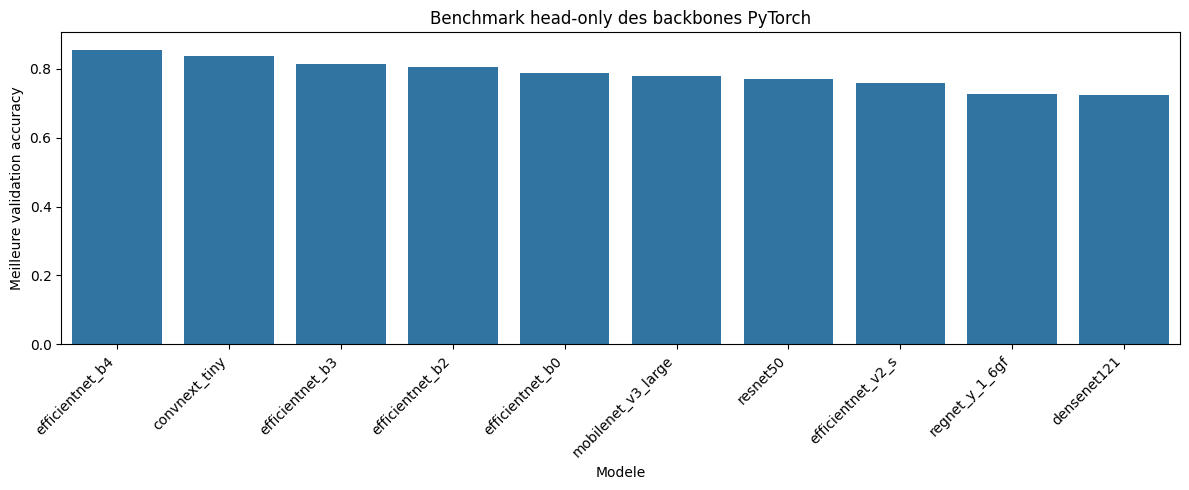

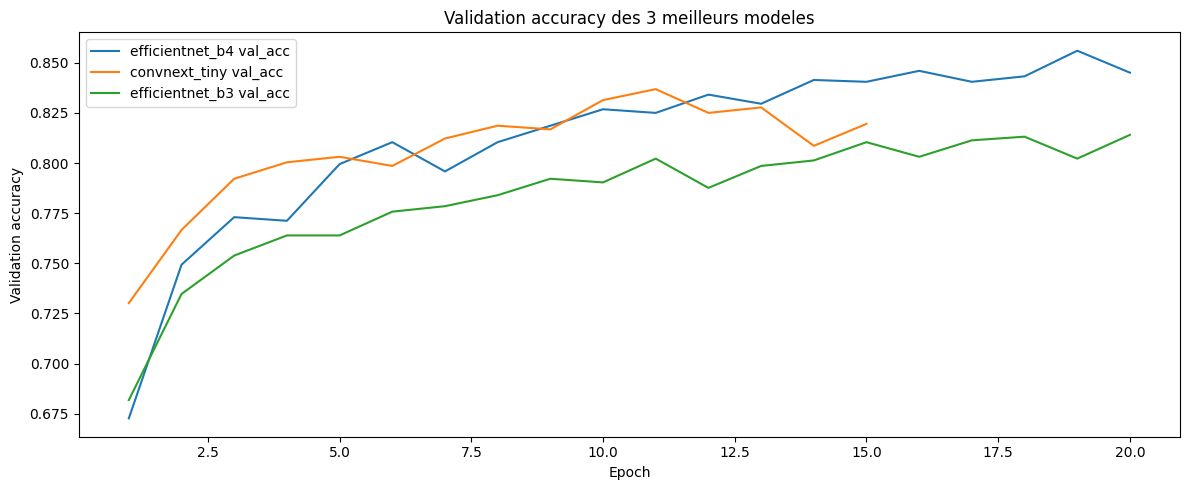

In [16]:
# Visualisation du classement head-only.

plt.figure(figsize=(12, 5))
sns.barplot(data=benchmark_results_df, x="model_name", y="best_val_accuracy")
plt.title("Benchmark head-only des backbones PyTorch")
plt.xlabel("Modele")
plt.ylabel("Meilleure validation accuracy")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, min(1.0, benchmark_results_df["best_val_accuracy"].max() + 0.05))
plt.tight_layout()
plt.show()

top_k_plot = 3
top_models_plot = benchmark_results_df.head(top_k_plot)["model_name"].tolist()

plt.figure(figsize=(12, 5))
for model_name in top_models_plot:
    history_df = benchmark_runs[model_name]["history"]
    plt.plot(history_df["epoch"], history_df["val_accuracy"], label=f"{model_name} val_acc")

plt.title(f"Validation accuracy des {top_k_plot} meilleurs modeles")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
# Evaluation multicritere sur la validation.
#
# Le benchmark head-only classe surtout par val_accuracy.
# Ici on fait le vrai classement robuste pour choisir les modeles
# a fine-tuner.


def evaluate_model_run(run: dict, dataframe: pd.DataFrame, split_name: str) -> dict:
    model_name = run["model_name"]
    dataloader = make_dataloader(dataframe, model_name=model_name, train=False, shuffle=False)
    eval_result = evaluate_dataloader(
        model=run["model"],
        dataloader=dataloader,
        criterion=None,
        split_name=split_name,
    )

    metrics = dict(eval_result["metrics"])
    metrics.update(
        {
            "model_name": model_name,
            "input_size": PT_MODELS[model_name]["input_size"],
            "batch_size": PT_MODELS[model_name]["batch_size"],
            "params_millions": run["params_millions"],
            "checkpoint_path": str(run["checkpoint_path"]),
        }
    )

    return {
        "metrics": metrics,
        "y_true": eval_result["y_true"],
        "y_pred": eval_result["y_pred"],
        "y_proba": eval_result["y_proba"],
    }


def evaluate_model_runs(model_runs: dict[str, dict], dataframe: pd.DataFrame, split_name: str):
    rows = []
    artifacts = {}

    for model_name, run in model_runs.items():
        evaluation = evaluate_model_run(run, dataframe=dataframe, split_name=split_name)
        artifacts[model_name] = evaluation
        rows.append(evaluation["metrics"])

    evaluation_df = pd.DataFrame(rows).sort_values(
        by=["ranking_score", "macro_f1", "balanced_accuracy", "accuracy", "top_3_accuracy", "log_loss"],
        ascending=[False, False, False, False, False, True],
    ).reset_index(drop=True)

    return evaluation_df, artifacts


head_eval_df, head_eval_artifacts = evaluate_model_runs(
    benchmark_runs,
    dataframe=df_val,
    split_name="val",
)

display(head_eval_df)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,ranking_score,split,loss,model_name,input_size,batch_size,params_millions,checkpoint_path
0,0.855971,0.848107,0.844970,0.848107,0.842180,0.855949,0.955333,0.497603,0.862310,val,NaN,efficientnet_b4,380,8,17.589855,/home/thomashebert99/code/thomashebert99/plant...
1,0.836828,0.826917,0.830867,0.826917,0.825251,0.837064,0.951686,0.548595,0.845874,val,NaN,convnext_tiny,224,24,27.837815,/home/thomashebert99/code/thomashebert99/plant...
2,0.814038,0.799451,0.801465,0.799451,0.794117,0.813588,0.942571,0.614658,0.819978,val,NaN,efficientnet_b3,300,24,10.731583,/home/thomashebert99/code/thomashebert99/plant...
3,0.804011,0.804043,0.790152,0.804043,0.790769,0.804759,0.940747,0.675299,0.818572,val,NaN,efficientnet_b2,288,32,7.733401,/home/thomashebert99/code/thomashebert99/plant...
4,0.786691,0.771612,0.770300,0.771612,0.763130,0.784522,0.936190,0.708473,0.793989,val,NaN,efficientnet_b0,224,48,4.037011,/home/thomashebert99/code/thomashebert99/plant...
5,0.780310,0.758416,0.761307,0.758416,0.755842,0.777990,0.930720,0.751281,0.785292,val,NaN,mobilenet_v3_large,224,48,4.231495,/home/thomashebert99/code/thomashebert99/plant...
6,0.771194,0.767053,0.753304,0.767053,0.754854,0.771053,0.912489,0.819578,0.783793,val,NaN,resnet50,224,48,23.555159,/home/thomashebert99/code/thomashebert99/plant...
7,0.757521,0.735890,0.732389,0.735890,0.725717,0.752521,0.926162,0.787167,0.762016,val,NaN,efficientnet_v2_s,384,4,20.206951,/home/thomashebert99/code/thomashebert99/plant...
8,0.724704,0.709196,0.719724,0.709196,0.703458,0.722889,0.904284,0.909893,0.737428,val,NaN,densenet121,224,32,6.977431,/home/thomashebert99/code/thomashebert99/plant...
9,0.726527,0.707443,0.709723,0.707443,0.700827,0.722639,0.905196,0.930966,0.736037,val,NaN,regnet_y_1_6gf,224,24,10.333877,/home/thomashebert99/code/thomashebert99/plant...


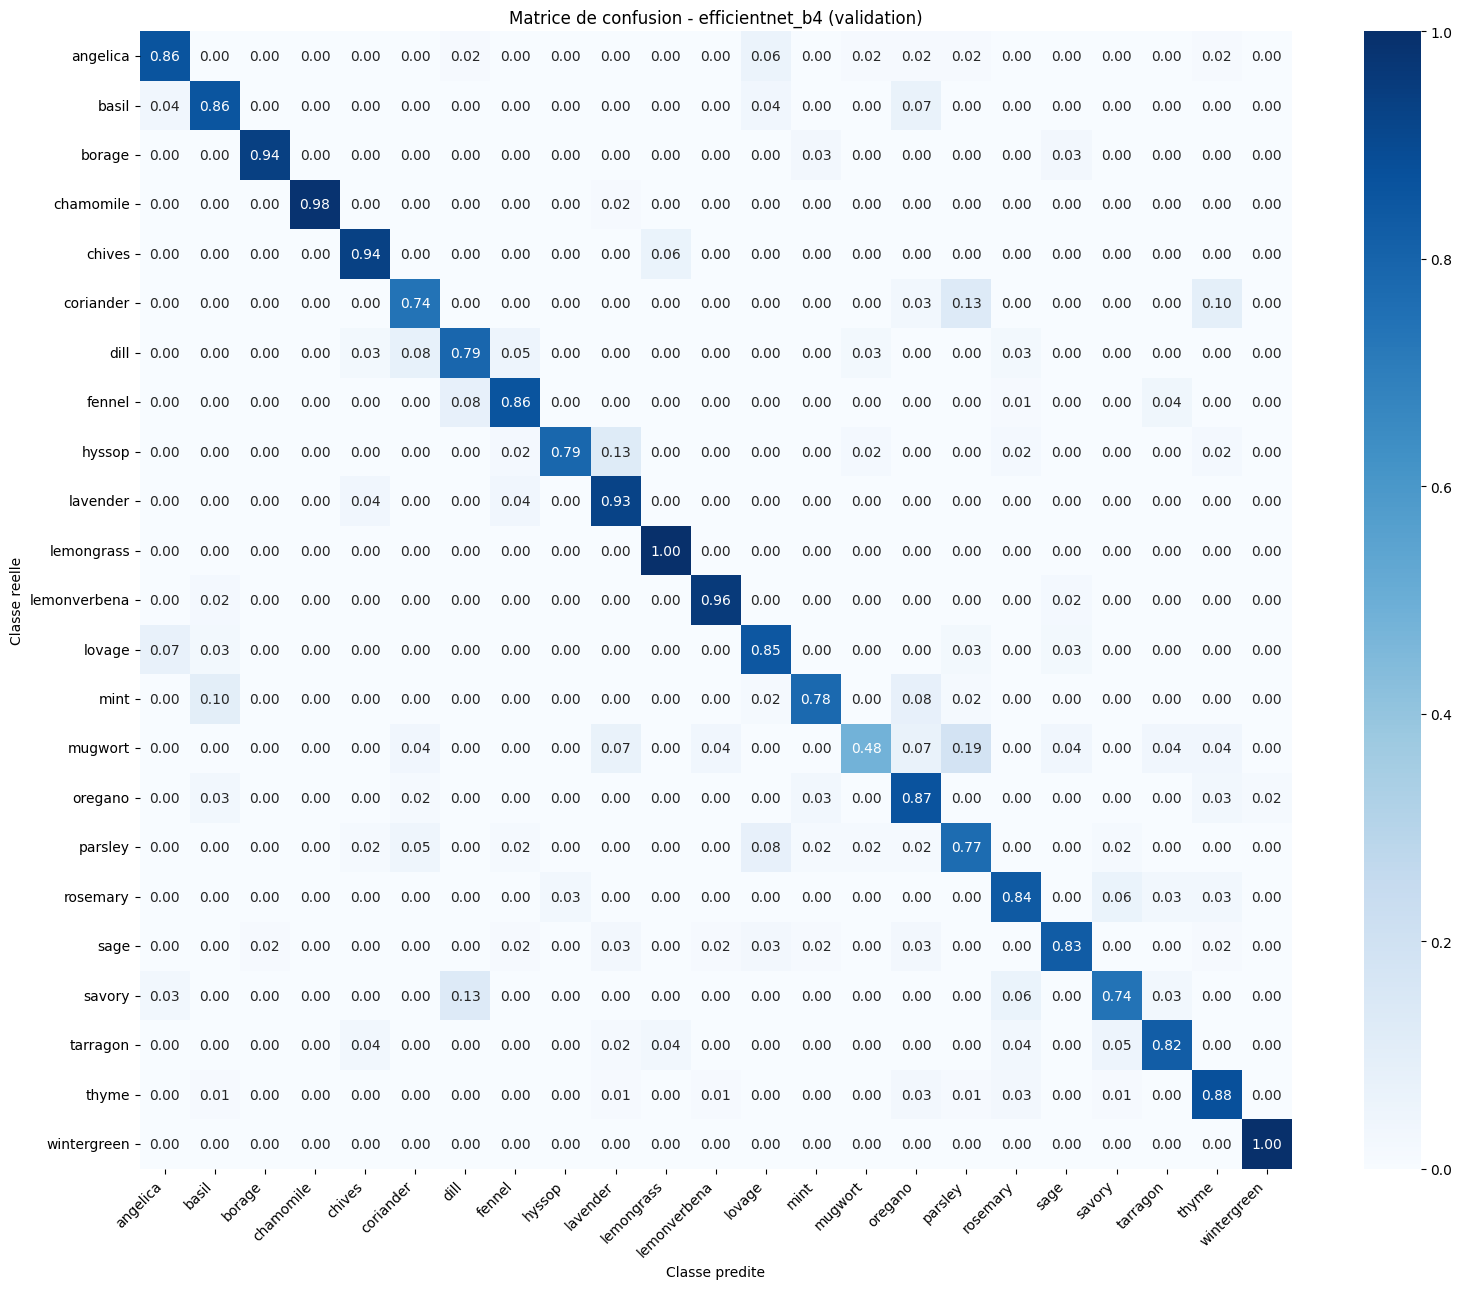

,precision,recall,f1-score,support
angelica,0.918033,0.861538,0.888889,65.000000
basil,0.685714,0.857143,0.761905,28.000000
borage,0.969697,0.941176,0.955224,34.000000
chamomile,1.000000,0.984848,0.992366,66.000000
chives,0.920635,0.935484,0.928000,62.000000
coriander,0.741935,0.741935,0.741935,31.000000
dill,0.731707,0.789474,0.759494,38.000000
fennel,0.911765,0.861111,0.885714,72.000000
hyssop,0.973684,0.787234,0.870588,47.000000
lavender,0.666667,0.928571,0.776119,28.000000


In [18]:
# Matrice de confusion et rapport detaille du meilleur modele head-only.

BEST_HEAD_MODEL_NAME = head_eval_df.loc[0, "model_name"]
best_head_eval = head_eval_artifacts[BEST_HEAD_MODEL_NAME]

cm = confusion_matrix(
    best_head_eval["y_true"],
    best_head_eval["y_pred"],
    labels=np.arange(NUM_CLASSES),
    normalize=CONFUSION_NORMALIZE,
)

cm_fmt = ".2f" if CONFUSION_NORMALIZE is not None else "d"

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm,
    annot=True,
    fmt=cm_fmt,
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title(f"Matrice de confusion - {BEST_HEAD_MODEL_NAME} (validation)")
plt.xlabel("Classe predite")
plt.ylabel("Classe reelle")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

best_head_report_df = pd.DataFrame(
    classification_report(
        best_head_eval["y_true"],
        best_head_eval["y_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T

display(best_head_report_df)

In [19]:
# Selection automatique des 4 meilleurs modeles pour le fine-tuning.

FINE_TUNE_TOP_N_MODELS = 2
TOP_MODELS_FOR_FINETUNING = head_eval_df.head(FINE_TUNE_TOP_N_MODELS)["model_name"].tolist()

print("Meilleur modele head-only :", BEST_HEAD_MODEL_NAME)
print("Top 2 retenus pour le fine-tuning :", TOP_MODELS_FOR_FINETUNING)
display(head_eval_df.head(FINE_TUNE_TOP_N_MODELS))

Meilleur modele head-only : efficientnet_b4
Top 2 retenus pour le fine-tuning : ['efficientnet_b4', 'convnext_tiny']


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,ranking_score,split,loss,model_name,input_size,batch_size,params_millions,checkpoint_path
0,0.855971,0.848107,0.844970,0.848107,0.842180,0.855949,0.955333,0.497603,0.862310,val,NaN,efficientnet_b4,380,8,17.589855,/home/thomashebert99/code/thomashebert99/plant...
1,0.836828,0.826917,0.830867,0.826917,0.825251,0.837064,0.951686,0.548595,0.845874,val,NaN,convnext_tiny,224,24,27.837815,/home/thomashebert99/code/thomashebert99/plant...


In [20]:
# Espace de recherche pour le fine-tuning.
#
# On garde une recherche volontairement compacte pour rester praticable.
# Si tu veux aller plus loin, passe RUN_EXHAUSTIVE_FINE_TUNE_SEARCH a True.

RUN_EXHAUSTIVE_FINE_TUNE_SEARCH = False
MAX_TRIALS_PER_MODEL = 3
FINE_TUNE_MAX_EPOCHS = 20

FINE_TUNE_SEARCH_SPACE = {
    "unfreeze_fraction": [0.20, 0.40],
    "learning_rate": [1e-5, 3e-5],
    "label_smoothing": [0.0, 0.05],
    "fine_tune_epochs": [FINE_TUNE_MAX_EPOCHS],
    "use_class_weights": [USE_CLASS_WEIGHTS],
    "freeze_batchnorm": [True],
}


def build_search_configs(search_space: dict, exhaustive: bool = False, max_trials: int = 8, seed: int = SEED):
    keys = list(search_space.keys())
    all_configs = [dict(zip(keys, values)) for values in product(*search_space.values())]

    rng = random.Random(seed)
    rng.shuffle(all_configs)

    if exhaustive or len(all_configs) <= max_trials:
        return all_configs

    return all_configs[:max_trials]


print("Recherche exhaustive :", RUN_EXHAUSTIVE_FINE_TUNE_SEARCH)
print("Nombre max de trials par modele :", MAX_TRIALS_PER_MODEL)
print("Top 2 modeles selectionnes :", TOP_MODELS_FOR_FINETUNING)

Recherche exhaustive : False
Nombre max de trials par modele : 3
Top 2 modeles selectionnes : ['efficientnet_b4', 'convnext_tiny']


In [21]:
# Fonction d'un trial de fine-tuning.
#
# On repart du meilleur checkpoint head-only du modele,
# puis on degel une partie du backbone.


def fine_tune_single_trial(
    model_name: str,
    base_checkpoint_path: Path,
    config: dict,
    df_train: pd.DataFrame,
    df_val: pd.DataFrame,
    trial_name: str,
):
    model, _ = load_model_from_checkpoint(base_checkpoint_path)
    model = model.to(DEVICE)

    n_unfreeze_blocks, trainable_backbone_params = set_fine_tune_layers(
        model=model,
        model_name=model_name,
        unfreeze_fraction=config["unfreeze_fraction"],
        freeze_batchnorm=config["freeze_batchnorm"],
    )

    train_loader = make_dataloader(df_train, model_name=model_name, train=True, shuffle=True)
    val_loader = make_dataloader(df_val, model_name=model_name, train=False, shuffle=False)

    class_weights = build_class_weight_tensor(df_train) if config["use_class_weights"] else None
    criterion = build_criterion(
        class_weights=class_weights,
        label_smoothing=config["label_smoothing"],
    )

    optimizer = torch.optim.AdamW(
        [param for param in model.parameters() if param.requires_grad],
        lr=config["learning_rate"],
        weight_decay=WEIGHT_DECAY,
    )

    checkpoint_path = MODEL_SAVE_DIR / f"{model_name}_{trial_name}_finetune_best.pt"
    run_config = {
        "phase": "fine_tune",
        "dropout_rate": DROPOUT_RATE,
        "learning_rate": config["learning_rate"],
        "epochs": config["fine_tune_epochs"],
        "batch_size": PT_MODELS[model_name]["batch_size"],
        "input_size": PT_MODELS[model_name]["input_size"],
        "use_class_weights": config["use_class_weights"],
        "label_smoothing": config["label_smoothing"],
        "unfreeze_fraction": config["unfreeze_fraction"],
        "freeze_batchnorm": config["freeze_batchnorm"],
    }

    start_time = time.time()
    run = fit_model(
        model=model,
        model_name=model_name,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        epochs=config["fine_tune_epochs"],
        checkpoint_path=checkpoint_path,
        run_config=run_config,
        monitor_metric="val_ranking_score",
        monitor_mode="max",
        scheduler_metric="val_ranking_score",
        scheduler_mode="max",
        patience=EARLY_STOPPING_PATIENCE,
        freeze_batchnorm=config["freeze_batchnorm"],
    )

    run["params_millions"] = count_params_millions(run["model"])

    train_time_min = (time.time() - start_time) / 60
    history_df = run["history"]
    best_idx = history_df["val_ranking_score"].idxmax()

    evaluation = evaluate_model_run(run, dataframe=df_val, split_name="val")
    metrics = dict(evaluation["metrics"])
    metrics.update(
        {
            "model_name": model_name,
            "trial_name": trial_name,
            "best_epoch": int(history_df.loc[best_idx, "epoch"]),
            "epochs_ran": len(history_df),
            "train_time_min": train_time_min,
            "fine_tune_learning_rate": config["learning_rate"],
            "fine_tune_epochs": config["fine_tune_epochs"],
            "label_smoothing": config["label_smoothing"],
            "unfreeze_fraction": config["unfreeze_fraction"],
            "freeze_batchnorm": config["freeze_batchnorm"],
            "use_class_weights": config["use_class_weights"],
            "requested_unfreeze_blocks": n_unfreeze_blocks,
            "trainable_backbone_params": trainable_backbone_params,
            "checkpoint_path": str(checkpoint_path),
            "base_checkpoint_path": str(base_checkpoint_path),
        }
    )

    return {
        "model_name": model_name,
        "trial_name": trial_name,
        "config": config,
        "metrics": metrics,
        "checkpoint_path": checkpoint_path,
        "model": run["model"],
        "history": history_df,
    }

In [22]:
# Lancer la recherche de fine-tuning sur les 4 meilleurs modeles.

fine_tune_trial_rows: list[dict] = []
best_fine_tune_trials: dict[str, dict] = {}

for model_rank, model_name in enumerate(TOP_MODELS_FOR_FINETUNING, start=1):
    print(f"\n{'=' * 20} Fine-tuning search: {model_name} {'=' * 20}")

    base_checkpoint_path = Path(benchmark_runs[model_name]["checkpoint_path"])
    trial_configs = build_search_configs(
        FINE_TUNE_SEARCH_SPACE,
        exhaustive=RUN_EXHAUSTIVE_FINE_TUNE_SEARCH,
        max_trials=MAX_TRIALS_PER_MODEL,
        seed=SEED + model_rank,
    )

    print(f"Nombre de configurations testees pour {model_name} : {len(trial_configs)}")

    for trial_idx, config in enumerate(trial_configs, start=1):
        print(f"\n--- {model_name} | trial {trial_idx:02d}/{len(trial_configs)} ---")
        print(config)
        clear_memory()

        trial_name = f"trial_{trial_idx:02d}"
        trial_result = fine_tune_single_trial(
            model_name=model_name,
            base_checkpoint_path=base_checkpoint_path,
            config=config,
            df_train=df_train,
            df_val=df_val,
            trial_name=trial_name,
        )

        fine_tune_trial_rows.append(trial_result["metrics"])

        current_best = best_fine_tune_trials.get(model_name)
        if current_best is None or trial_result["metrics"]["ranking_score"] > current_best["metrics"]["ranking_score"]:
            best_fine_tune_trials[model_name] = trial_result

fine_tune_trials_df = pd.DataFrame(fine_tune_trial_rows).sort_values(
    by=["ranking_score", "macro_f1", "balanced_accuracy", "accuracy", "top_3_accuracy", "log_loss"],
    ascending=[False, False, False, False, False, True],
).reset_index(drop=True)

display(fine_tune_trials_df)


==================== Fine-tuning search: efficientnet_b4 ====================
Nombre de configurations testees pour efficientnet_b4 : 3

--- efficientnet_b4 | trial 01/3 ---
{'unfreeze_fraction': 0.4, 'learning_rate': 3e-05, 'label_smoothing': 0.0, 'fine_tune_epochs': 20, 'use_class_weights': True, 'freeze_batchnorm': True}
Epoch 01: new best val_ranking_score=0.8805 -> checkpoint saved to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models_pt/efficientnet_b4_trial_01_finetune_best.pt
Epoch 01/20 | train_loss=0.4163 | train_acc=0.8713 | val_loss=0.4258 | val_acc=0.8724 | val_macro_f1=0.8627 | val_rank=0.8805 | lr=3.00e-05
Epoch 02: new best val_ranking_score=0.8941 -> checkpoint saved to /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/models_pt/efficientnet_b4_trial_01_finetune_best.pt
Epoch 02/20 | train_loss=0.3345 | train_acc=0.8937 | val_loss=0.3761 | val_acc=0.8861 | val_macro_f1=0.8767 | val_rank=0.8941 | lr=3.00e-05
Epoch 03: new best val_rank

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,ranking_score,split,...,train_time_min,fine_tune_learning_rate,fine_tune_epochs,label_smoothing,unfreeze_fraction,freeze_batchnorm,use_class_weights,requested_unfreeze_blocks,trainable_backbone_params,base_checkpoint_path
0,0.936190,0.932750,0.929997,0.932750,0.929968,0.936193,0.984503,0.292646,0.939605,val,...,9.987691,0.00003,20,0.05,0.4,True,True,4,16119004,/home/thomashebert99/code/thomashebert99/plant...
1,0.933455,0.927663,0.926555,0.927663,0.925846,0.933213,0.990884,0.242870,0.936908,val,...,8.468766,0.00003,20,0.00,0.4,True,True,4,16119004,/home/thomashebert99/code/thomashebert99/plant...
2,0.920693,0.914701,0.915383,0.914701,0.913729,0.920876,0.987238,0.263480,0.925743,val,...,10.112324,0.00001,20,0.00,0.4,True,True,4,16119004,/home/thomashebert99/code/thomashebert99/plant...
3,0.907931,0.906932,0.902288,0.906932,0.901895,0.908613,0.976299,0.387844,0.915170,val,...,2.639058,0.00001,20,0.05,0.4,True,True,4,26583552,/home/thomashebert99/code/thomashebert99/plant...
4,0.884230,0.873614,0.876255,0.873614,0.873219,0.884068,0.961714,0.440133,0.887713,val,...,2.475620,0.00003,20,0.00,0.2,True,True,2,15470592,/home/thomashebert99/code/thomashebert99/plant...
5,0.873291,0.870753,0.861506,0.870753,0.863515,0.874464,0.966272,0.489251,0.882078,val,...,2.499888,0.00003,20,0.05,0.2,True,True,2,15470592,/home/thomashebert99/code/thomashebert99/plant...


In [23]:
# Meilleure configuration retenue pour chaque modele.

best_fine_tune_df = pd.DataFrame(
    [trial["metrics"] for trial in best_fine_tune_trials.values()]
).sort_values(
    by=["ranking_score", "macro_f1", "balanced_accuracy", "accuracy", "top_3_accuracy", "log_loss"],
    ascending=[False, False, False, False, False, True],
).reset_index(drop=True)

display(best_fine_tune_df)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,ranking_score,split,...,train_time_min,fine_tune_learning_rate,fine_tune_epochs,label_smoothing,unfreeze_fraction,freeze_batchnorm,use_class_weights,requested_unfreeze_blocks,trainable_backbone_params,base_checkpoint_path
0,0.936190,0.932750,0.929997,0.932750,0.929968,0.936193,0.984503,0.292646,0.939605,val,...,9.987691,0.00003,20,0.05,0.4,True,True,4,16119004,/home/thomashebert99/code/thomashebert99/plant...
1,0.907931,0.906932,0.902288,0.906932,0.901895,0.908613,0.976299,0.387844,0.915170,val,...,2.639058,0.00001,20,0.05,0.4,True,True,4,26583552,/home/thomashebert99/code/thomashebert99/plant...


In [24]:
# Evaluation finale sur le split test avec les meilleurs modeles fine-tunes.

best_fine_tune_runs = {
    model_name: {
        "model_name": trial["model_name"],
        "model": trial["model"],
        "checkpoint_path": trial["checkpoint_path"],
        "trial_name": trial["trial_name"],
        "config": trial["config"],
        "params_millions": count_params_millions(trial["model"]),
    }
    for model_name, trial in best_fine_tune_trials.items()
}

fine_tuned_test_eval_df, fine_tuned_test_eval_artifacts = evaluate_model_runs(
    best_fine_tune_runs,
    dataframe=df_test,
    split_name="test",
)

display(fine_tuned_test_eval_df)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,ranking_score,split,loss,model_name,input_size,batch_size,params_millions,checkpoint_path
0,0.915301,0.907991,0.912767,0.907991,0.908420,0.914918,0.982696,0.336466,0.920121,test,NaN,efficientnet_b4,380,8,17.589855,/home/thomashebert99/code/thomashebert99/plant...
1,0.872495,0.864959,0.863637,0.864959,0.862441,0.872582,0.965392,0.442090,0.879644,test,NaN,convnext_tiny,224,24,27.837815,/home/thomashebert99/code/thomashebert99/plant...


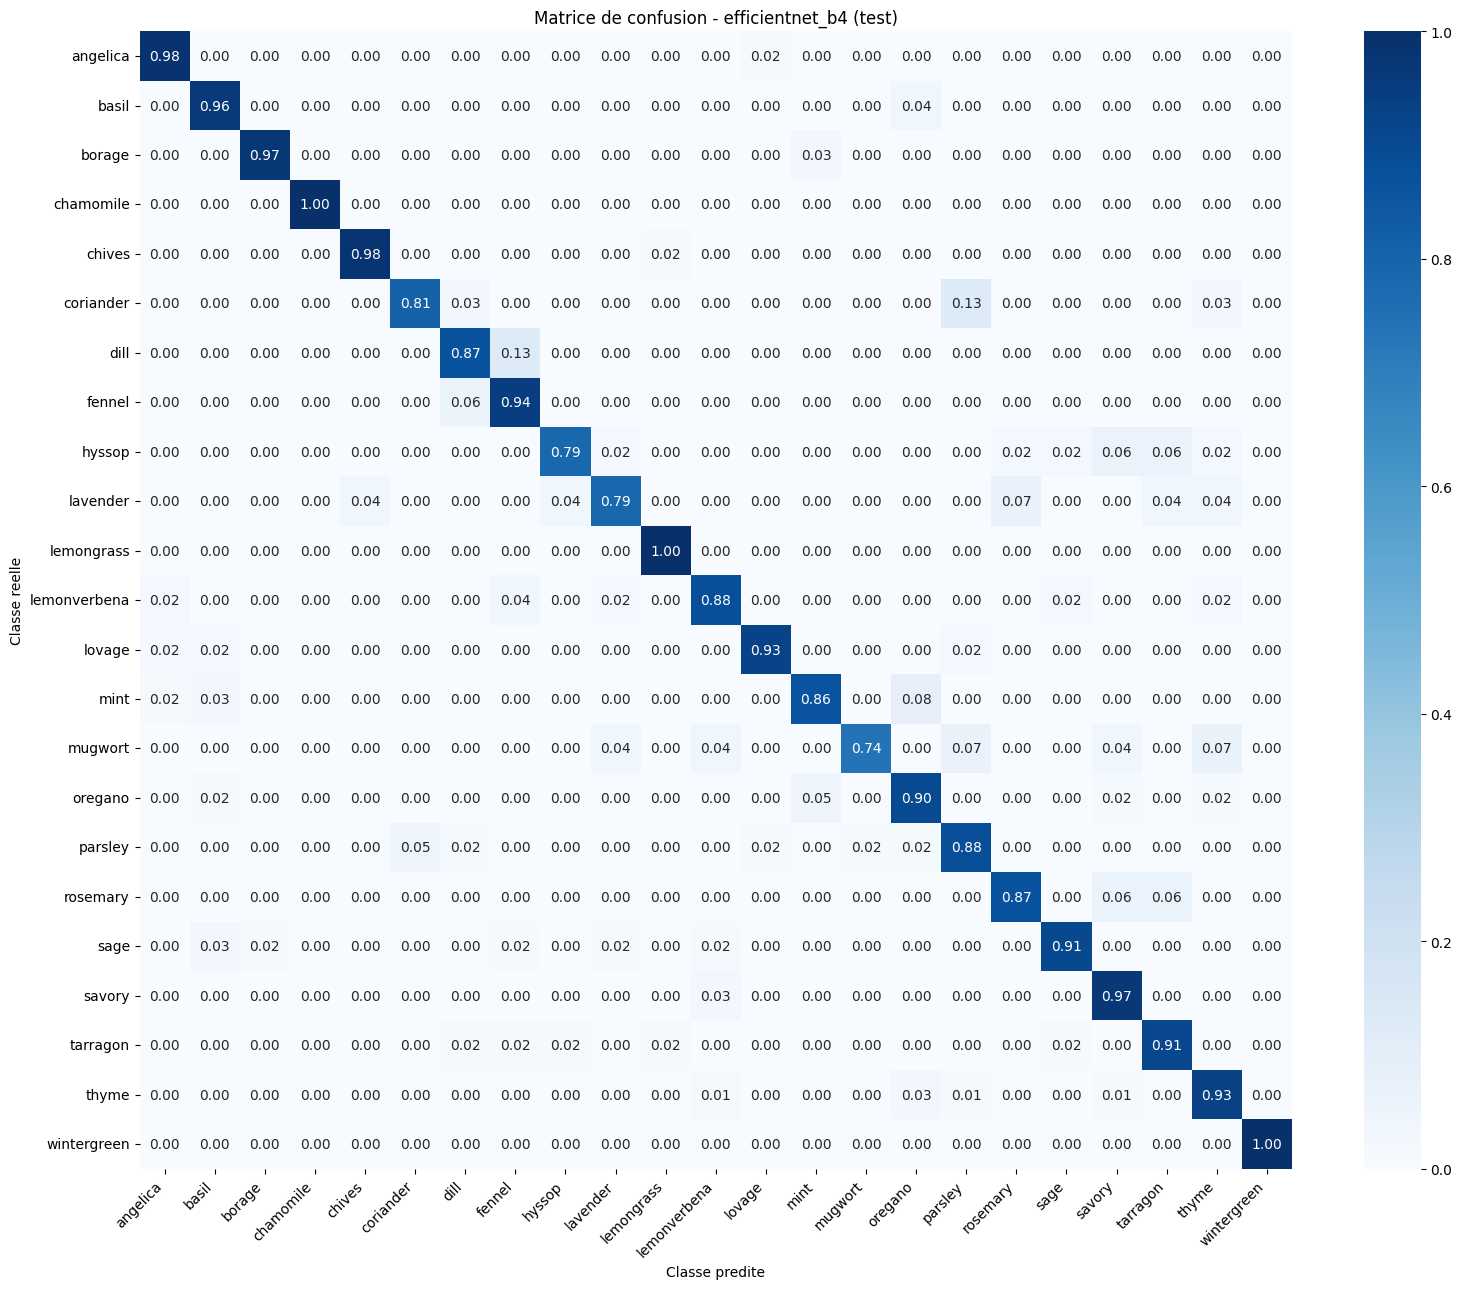

In [25]:
# Matrice de confusion du meilleur modele apres fine-tuning.

BEST_FINE_TUNED_MODEL_NAME = fine_tuned_test_eval_df.loc[0, "model_name"]
best_fine_tuned_eval = fine_tuned_test_eval_artifacts[BEST_FINE_TUNED_MODEL_NAME]

cm = confusion_matrix(
    best_fine_tuned_eval["y_true"],
    best_fine_tuned_eval["y_pred"],
    labels=np.arange(NUM_CLASSES),
    normalize=CONFUSION_NORMALIZE,
)

cm_fmt = ".2f" if CONFUSION_NORMALIZE is not None else "d"

plt.figure(figsize=(16, 13))
sns.heatmap(
    cm,
    annot=True,
    fmt=cm_fmt,
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title(f"Matrice de confusion - {BEST_FINE_TUNED_MODEL_NAME} (test)")
plt.xlabel("Classe predite")
plt.ylabel("Classe reelle")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
# Rapport detaille final et configuration gagnante.

best_fine_tuned_report_df = pd.DataFrame(
    classification_report(
        best_fine_tuned_eval["y_true"],
        best_fine_tuned_eval["y_pred"],
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
).T

FINAL_MODEL_RANKING = fine_tuned_test_eval_df["model_name"].tolist()
WINNING_CONFIG = best_fine_tune_trials[BEST_FINE_TUNED_MODEL_NAME]["config"]

print("Meilleur modele final apres fine-tuning :", BEST_FINE_TUNED_MODEL_NAME)
print("Classement final des modeles :", FINAL_MODEL_RANKING)
print("Configuration gagnante :")
print(WINNING_CONFIG)

display(best_fine_tuned_report_df)

Meilleur modele final apres fine-tuning : efficientnet_b4
Classement final des modeles : ['efficientnet_b4', 'convnext_tiny']
Configuration gagnante :
{'unfreeze_fraction': 0.4, 'learning_rate': 3e-05, 'label_smoothing': 0.05, 'fine_tune_epochs': 20, 'use_class_weights': True, 'freeze_batchnorm': True}


,precision,recall,f1-score,support
angelica,0.955224,0.984615,0.969697,65.000000
basil,0.818182,0.964286,0.885246,28.000000
borage,0.970588,0.970588,0.970588,34.000000
chamomile,1.000000,1.000000,1.000000,66.000000
chives,0.983871,0.983871,0.983871,62.000000
coriander,0.892857,0.806452,0.847458,31.000000
dill,0.825000,0.868421,0.846154,38.000000
fennel,0.883117,0.944444,0.912752,72.000000
hyssop,0.948718,0.787234,0.860465,47.000000
lavender,0.846154,0.785714,0.814815,28.000000


Modele analyse pour l'overfitting : efficientnet_b4
Source : fine_tuned


,model_name,split,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,log_loss,ranking_score
0,efficientnet_b4,train,0.997070,0.996783,0.997150,0.996783,0.996952,0.997068,1.000000,0.070634,0.997370
1,efficientnet_b4,val,0.936190,0.932750,0.929997,0.932750,0.929968,0.936193,0.984503,0.292646,0.939605
2,efficientnet_b4,test,0.915301,0.907991,0.912767,0.907991,0.908420,0.914918,0.982696,0.336466,0.920121


,model_name,train_accuracy,val_accuracy,test_accuracy,train_macro_f1,val_macro_f1,test_macro_f1,gap_train_val_accuracy,gap_train_test_accuracy,gap_train_val_macro_f1,gap_train_test_macro_f1,overfitting_level
0,efficientnet_b4,0.99707,0.93619,0.915301,0.996952,0.929968,0.90842,0.06088,0.081769,0.066983,0.088531,Modere


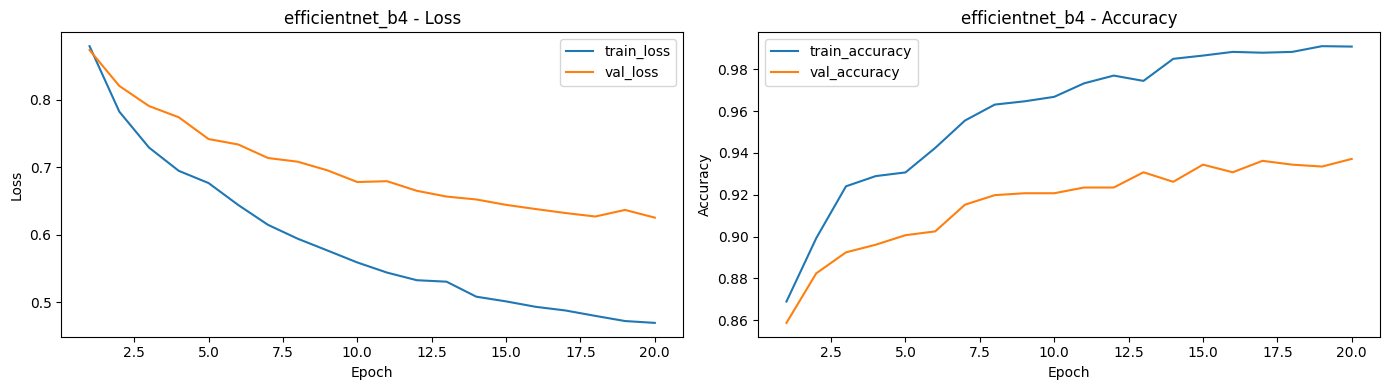

Niveau estime d'overfitting : Modere
Gap train-val accuracy : 0.0609
Gap train-val macro_f1 : 0.0670
Conclusion : un overfitting modere est present. Le modele reste exploitable, mais a surveiller.


In [27]:
# Evaluation de l'overfitting du meilleur modele final.
#
# Cette cellule :
# - choisit automatiquement le meilleur modele disponible
# - compare les performances train / val / test
# - mesure les ecarts pour estimer l'overfitting
# - affiche aussi les courbes d'apprentissage si l'historique est disponible

def classify_overfitting(train_acc, val_acc, train_f1, val_f1):
    acc_gap = train_acc - val_acc
    f1_gap = train_f1 - val_f1

    if acc_gap < 0.03 and f1_gap < 0.03:
        return "Faible"
    if acc_gap < 0.08 and f1_gap < 0.08:
        return "Modere"
    return "Eleve"


# 1. Choisir le meilleur modele disponible
if "best_fine_tune_runs" in globals() and len(best_fine_tune_runs) > 0:
    selected_model_name = fine_tuned_test_eval_df.loc[0, "model_name"]
    selected_run = best_fine_tune_runs[selected_model_name]
    selected_history = best_fine_tune_trials[selected_model_name]["history"]
    selected_source = "fine_tuned"
else:
    selected_model_name = head_eval_df.loc[0, "model_name"]
    selected_run = benchmark_runs[selected_model_name]
    selected_history = benchmark_runs[selected_model_name]["history"]
    selected_source = "head_only"

print("Modele analyse pour l'overfitting :", selected_model_name)
print("Source :", selected_source)


# 2. Evaluer train / val / test avec les memes metriques
train_overfit_eval = evaluate_model_run(selected_run, dataframe=df_train, split_name="train")
val_overfit_eval = evaluate_model_run(selected_run, dataframe=df_val, split_name="val")
test_overfit_eval = evaluate_model_run(selected_run, dataframe=df_test, split_name="test")

overfit_df = pd.DataFrame(
    [
        train_overfit_eval["metrics"],
        val_overfit_eval["metrics"],
        test_overfit_eval["metrics"],
    ]
)[
    [
        "model_name",
        "split",
        "accuracy",
        "balanced_accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "top_3_accuracy",
        "log_loss",
        "ranking_score",
    ]
]

display(overfit_df)


# 3. Calculer les ecarts train -> val / test
train_metrics = train_overfit_eval["metrics"]
val_metrics = val_overfit_eval["metrics"]
test_metrics = test_overfit_eval["metrics"]

overfit_summary = pd.DataFrame(
    [
        {
            "model_name": selected_model_name,
            "train_accuracy": train_metrics["accuracy"],
            "val_accuracy": val_metrics["accuracy"],
            "test_accuracy": test_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
            "val_macro_f1": val_metrics["macro_f1"],
            "test_macro_f1": test_metrics["macro_f1"],
            "gap_train_val_accuracy": train_metrics["accuracy"] - val_metrics["accuracy"],
            "gap_train_test_accuracy": train_metrics["accuracy"] - test_metrics["accuracy"],
            "gap_train_val_macro_f1": train_metrics["macro_f1"] - val_metrics["macro_f1"],
            "gap_train_test_macro_f1": train_metrics["macro_f1"] - test_metrics["macro_f1"],
            "overfitting_level": classify_overfitting(
                train_metrics["accuracy"],
                val_metrics["accuracy"],
                train_metrics["macro_f1"],
                val_metrics["macro_f1"],
            ),
        }
    ]
)

display(overfit_summary)


# 4. Courbes d'apprentissage
if selected_history is not None and len(selected_history) > 0:
    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    plt.plot(selected_history["epoch"], selected_history["train_loss"], label="train_loss")
    plt.plot(selected_history["epoch"], selected_history["val_loss"], label="val_loss")
    plt.title(f"{selected_model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(selected_history["epoch"], selected_history["train_accuracy"], label="train_accuracy")
    plt.plot(selected_history["epoch"], selected_history["val_accuracy"], label="val_accuracy")
    plt.title(f"{selected_model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


# 5. Interpretation automatique
acc_gap = overfit_summary.loc[0, "gap_train_val_accuracy"]
f1_gap = overfit_summary.loc[0, "gap_train_val_macro_f1"]
level = overfit_summary.loc[0, "overfitting_level"]

print(f"Niveau estime d'overfitting : {level}")
print(f"Gap train-val accuracy : {acc_gap:.4f}")
print(f"Gap train-val macro_f1 : {f1_gap:.4f}")

if level == "Faible":
    print("Conclusion : le modele generalise plutot bien, peu de signe d'overfitting.")
elif level == "Modere":
    print("Conclusion : un overfitting modere est present. Le modele reste exploitable, mais a surveiller.")
else:
    print("Conclusion : le modele montre un overfitting marque. Il faudrait envisager moins de capacite, plus de regularisation ou moins de fine-tuning.")


In [30]:
# Sauvegarder le meilleur modele + les labels avec une nomenclature datee
#
# Exemple de nom :
# EFFICIENTNET_B4_2203-1044.pt
# EFFICIENTNET_B4_2203-1044_labels.pkl
# EFFICIENTNET_B4_2203-1044_metadata.pkl

import pickle
import re
from datetime import datetime
from pathlib import Path

EXPORT_DIR = PROJECT_DIR / "notebooks" / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Choisir automatiquement le meilleur modele disponible
if "best_fine_tune_runs" in globals() and len(best_fine_tune_runs) > 0:
    export_model_name = fine_tuned_test_eval_df.loc[0, "model_name"]
    export_run = best_fine_tune_runs[export_model_name]
    export_source = "fine_tuned"
    export_config = export_run.get("config", {})
else:
    export_model_name = head_eval_df.loc[0, "model_name"]
    export_run = benchmark_runs[export_model_name]
    export_source = "head_only"
    export_config = export_run.get("run_config", {})

# Nomenclature : NOMDUMODELE_JJMM-hhmm
timestamp = datetime.now().strftime("%d%m-%H%M")
safe_model_name = re.sub(r"[^A-Z0-9_]+", "_", export_model_name.upper())
base_name = f"{safe_model_name}_{timestamp}"

model_path = EXPORT_DIR / f"{base_name}.pt"
labels_path = EXPORT_DIR / f"{base_name}_labels.pkl"
metadata_path = EXPORT_DIR / f"{base_name}_metadata.pkl"

# 1. Sauvegarde du modele PyTorch
model_to_save = export_run["model"].cpu()
torch.save(model_to_save.state_dict(), model_path)

# 2. Sauvegarde de l'equivalent du label encoder
label_encoder_payload = {
    "class_names": CLASS_NAMES,
    "label_to_index": label_to_index,
    "index_to_label": index_to_label,
    "num_classes": NUM_CLASSES,
}

with open(labels_path, "wb") as f:
    pickle.dump(label_encoder_payload, f)

# 3. Sauvegarde des metadonnees utiles pour recharger correctement le modele
metadata_payload = {
    "model_name": export_model_name,
    "source": export_source,
    "num_classes": NUM_CLASSES,
    "dropout_rate": DROPOUT_RATE,
    "config": export_config,
    "model_path": str(model_path),
    "labels_path": str(labels_path),
}

with open(metadata_path, "wb") as f:
    pickle.dump(metadata_payload, f)

print("Modele sauvegarde   :", model_path)
print("Labels sauvegardes  :", labels_path)
print("Metadata sauvegarde :", metadata_path)
print("Modele exporte      :", export_model_name)
print("Source              :", export_source)

Modele sauvegarde   : /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/exports/EFFICIENTNET_B4_2203-1305.pt
Labels sauvegardes  : /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/exports/EFFICIENTNET_B4_2203-1305_labels.pkl
Metadata sauvegarde : /home/thomashebert99/code/thomashebert99/plant_detect/notebooks/exports/EFFICIENTNET_B4_2203-1305_metadata.pkl
Modele exporte      : efficientnet_b4
Source              : fine_tuned


In [29]:
# Recharger le modele + l'encodeur de labels depuis le .pkl

import pickle

pkl_path = model_pkl_path  # ou mets le chemin exact

with open(pkl_path, "rb") as f:
    saved = pickle.load(f)

loaded_model = build_transfer_model(
    model_name=saved["model_name"],
    num_classes=saved["num_classes"],
    dropout_rate=DROPOUT_RATE,
)
loaded_model.load_state_dict(saved["state_dict"])
loaded_model = loaded_model.to(DEVICE).eval()

loaded_class_names = saved["class_names"]
loaded_label_to_index = saved["label_to_index"]
loaded_index_to_label = saved["index_to_label"]

print("Modele recharge :", saved["model_name"])
print("Classes :", loaded_class_names)


Modele recharge : efficientnet_b4
Classes : ['angelica', 'basil', 'borage', 'chamomile', 'chives', 'coriander', 'dill', 'fennel', 'hyssop', 'lavender', 'lemongrass', 'lemonverbena', 'lovage', 'mint', 'mugwort', 'oregano', 'parsley', 'rosemary', 'sage', 'savory', 'tarragon', 'thyme', 'wintergreen']
